<a href="https://colab.research.google.com/github/daisy21107/fyp-progressive-copying-pruning/blob/rq1-trajectory-comparison/FYP_Convergence_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
!git clone -b rq1-trajectory-comparison https://github.com/daisy21107/fyp-progressive-copying-pruning.git

fatal: destination path 'fyp-progressive-copying-pruning' already exists and is not an empty directory.


# Task
Mount Google Drive, verify GPU availability, install Python dependencies from `requirements.txt` in the cloned repository, and verify the existence of `scripts/analyze_convergence.py` for the convergence study.

## Colab Notebook Setup

### Subtask:
Mount Google Drive, verify GPU availability, install Python dependencies from `requirements.txt`, and verify the existence of `scripts/analyze_convergence.py`.


**Reasoning**:
The first instruction is to mount Google Drive. I will generate a code block to mount Google Drive to '/content/drive'.



In [23]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.


**Reasoning**:
The next step is to verify GPU availability, as per the subtask instructions. I will use the `nvidia-smi` command for this.



In [24]:
import subprocess
try:
    subprocess.run(['nvidia-smi'], check=True)
    print("GPU is available and configured.")
except (subprocess.CalledProcessError, FileNotFoundError):
    print("No GPU found or nvidia-smi command not available.")


GPU is available and configured.


**Reasoning**:
The next step is to change the current working directory to the cloned repository, as specified in the subtask instructions. I will use the `os.chdir()` function for this purpose, using the `repo_root` variable which holds the path to the cloned repository.



In [25]:
import os

repo_root = '/content/fyp-progressive-copying-pruning'
os.chdir(repo_root)
print(f"Changed current working directory to: {os.getcwd()}")

Changed current working directory to: /content/fyp-progressive-copying-pruning


In [26]:
import subprocess
try:
    subprocess.run(['pip', 'install', '-r', 'requirements.txt'], check=True)
    print("Python dependencies installed successfully.")
except subprocess.CalledProcessError as e:
    print(f"Error installing dependencies: {e}")
except FileNotFoundError:
    print("requirements.txt not found. Please ensure it exists in the current directory.")

Python dependencies installed successfully.


### Reload GitHub Repository

To update the local repository with the latest changes from the remote, we will use the `git pull` command. First, ensure we are in the correct directory, then execute the command.

In [27]:
import os
import subprocess

# Ensure we are in the repository's root directory
# Assuming repo_root is defined from previous steps
if 'repo_root' in locals() and os.path.isdir(repo_root):
    os.chdir(repo_root)
    print(f"Changed current working directory to: {os.getcwd()}")

    try:
        print("Pulling latest changes from GitHub...")
        result = subprocess.run(['git', 'pull'], check=True, capture_output=True)
        print("GitHub repository reloaded successfully.")
        print(f"Output: {result.stdout.decode('utf-8')}")
        if result.stderr:
            print(f"Errors (if any): {result.stderr.decode('utf-8')}")
    except subprocess.CalledProcessError as e:
        print(f"Error pulling from GitHub: {e}")
        if e.stdout:
            print(f"Standard Output: {e.stdout.decode('utf-8')}")
        if e.stderr:
            print(f"Standard Error: {e.stderr.decode('utf-8')}")
    except FileNotFoundError:
        print("Error: git command not found. Ensure Git is installed and in PATH.")
else:
    print("Error: Repository root directory not found or 'repo_root' variable not defined.")

Changed current working directory to: /content/fyp-progressive-copying-pruning
Pulling latest changes from GitHub...
GitHub repository reloaded successfully.
Output: Updating 0e71807..d8e8fea
Fast-forward
 FYP_Convergence_Study.ipynb | 1764 +++++++++++++++++++++++++++++++++++++++++++
 1 file changed, 1764 insertions(+)
 create mode 100644 FYP_Convergence_Study.ipynb

Errors (if any): From https://github.com/daisy21107/fyp-progressive-copying-pruning
   0e71807..d8e8fea  rq1-trajectory-comparison -> origin/rq1-trajectory-comparison



## Colab Notebook: "FYP_Convergence_Study"

### **Cell 1: Mount Drive & Setup**

In [28]:
# ============================================
# CONVERGENCE STUDY SETUP
# ============================================

from google.colab import drive
import os

# Ensure the mountpoint is clean before attempting to mount
if os.path.exists('/content/drive') and os.path.isdir('/content/drive'):
    try:
        for item in os.listdir('/content/drive'):
            item_path = os.path.join('/content/drive', item)
            if os.path.isfile(item_path) or os.path.islink(item_path):
                os.remove(item_path)
            elif os.path.isdir(item_path):
                os.rmdir(item_path) # Use rmdir for empty directories, shutil.rmtree for non-empty
    except OSError as e:
        # If it's not empty, try shutil.rmtree if it's a directory
        import shutil
        shutil.rmtree('/content/drive', ignore_errors=True)

drive.mount('/content/drive', force_remount=True)

import torch
print(f"✓ GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")

# Clone repo
!rm -rf fyp-progressive-copying-pruning
!git clone https://github.com/daisy21107/fyp-progressive-copying-pruning.git
%cd /content/fyp-progressive-copying-pruning

# Checkout RQ1 branch
!git checkout rq1-trajectory-comparison
!git pull origin rq1-trajectory-comparison

# Verify we have the convergence scripts
!ls -lh scripts/convergence_study.sh scripts/analyze_convergence.py

# Install dependencies
!pip install -q torch torchvision matplotlib pandas pyyaml tqdm

print("\n" + "="*70)
print("✓ SETUP COMPLETE")
print("✓ Branch: rq1-trajectory-comparison")
print("✓ Convergence scripts: Available")
print("="*70)

Mounted at /content/drive
✓ GPU: Tesla T4
Cloning into 'fyp-progressive-copying-pruning'...
remote: Enumerating objects: 297, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 297 (delta 44), reused 55 (delta 33), pack-reused 212 (from 1)
Receiving objects: 100% (297/297), 23.31 MiB | 20.07 MiB/s, done.
Resolving deltas: 100% (103/103), done.
/content
Already on 'rq1-trajectory-comparison'
Your branch is up to date with 'origin/rq1-trajectory-comparison'.
From https://github.com/daisy21107/fyp-progressive-copying-pruning
 * branch            rq1-trajectory-comparison -> FETCH_HEAD
Already up to date.
-rwxr-xr-x 1 root root 3.0K Apr 15 16:22 scripts/analyze_convergence.py
-rwxr-xr-x 1 root root  611 Apr 15 16:22 scripts/convergence_study.sh

✓ SETUP COMPLETE
✓ Branch: rq1-trajectory-comparison
✓ Convergence scripts: Available


### **Cell 2: Train Teacher (if needed)**

In [29]:
# ============================================
# TRAIN TEACHER (Skip if already done)
# ============================================

# Check if teacher already exists
import os
if os.path.exists('runs/cifar_teacher_final/teacher.pt'):
    print("✓ Teacher already exists, skipping training")
else:
    print("Training teacher model...")
    !python -m src.main teacher \
        --config configs/teacher_cifar100.yaml \
        --seed 42 \
        --out-dir runs/cifar_teacher_final
    print("✓ Teacher training complete")

Training teacher model...
100% 169M/169M [00:10<00:00, 16.1MB/s]
[Data] Task: cifar100_binary_pairs
[Data] Train pairs: 7000
[Data] Test pairs: 1400
[Data] Underwater classes: [1, 30, 32, 55, 67, 72, 73, 91, 95]
[Data] Food classes: [0, 51, 53, 57, 83]
[Data] Train label distribution: {0: 3806, 1: 3194}
[Data] Test label distribution: {1: 625, 0: 775}
[Data] Train sample pairs (first 10): [(0, 5520), (1, 2973), (2, 3393), (3, 4560), (4, 1509), (5, 1968), (6, 2109), (7, 2385), (8, 256), (9, 4655)]
[Data] Test sample pairs (first 10): [(0, 418), (1, 195), (2, 861), (3, 755), (4, 499), (5, 1192), (6, 523), (7, 181), (8, 824), (9, 554)]
Train E1: 100% 55/55 [00:06<00:00,  8.81it/s]
Val E1: 100% 11/11 [00:00<00:00, 17.64it/s]
Train E2: 100% 55/55 [00:03<00:00, 13.82it/s]
Val E2: 100% 11/11 [00:00<00:00, 17.36it/s]
Train E3: 100% 55/55 [00:04<00:00, 12.52it/s]
Val E3: 100% 11/11 [00:00<00:00, 12.31it/s]
Train E4: 100% 55/55 [00:04<00:00, 12.64it/s]
Val E4: 100% 11/11 [00:00<00:00, 17.24it/s]

### **Cell 3: Run Convergence Study**

In [30]:
# ============================================
# CONVERGENCE STUDY: TEST DIFFERENT EPOCH COUNTS
# ============================================
# Testing: 20, 30, 40, 50, 60 epochs
# Each run: ~30 minutes
# Total time: ~2.5-3 hours
# ============================================

import time
from datetime import datetime

epochs_to_test = [20, 30, 40, 50, 60]
start_time = time.time()

print("="*70)
print("CONVERGENCE STUDY STARTED")
print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Testing epochs: {epochs_to_test}")
print("="*70)

for i, epochs in enumerate(epochs_to_test, 1):
    print(f"\n{'='*70}")
    print(f"RUN {i}/{len(epochs_to_test)}: Testing {epochs} epochs")
    print(f"{'='*70}\n")

    run_start = time.time()

    !python -m src.main progressive \
        --config configs/rq1/progressive_90pct.yaml \
        --epochs {epochs} \
        --seed 0 \
        --out-dir runs/convergence/progressive_e{epochs}

    run_time = (time.time() - run_start) / 60
    elapsed = (time.time() - start_time) / 60
    remaining = (elapsed / i) * (len(epochs_to_test) - i)

    print(f"\n✓ {epochs} epochs complete ({run_time:.1f} minutes)")
    print(f"  Elapsed: {elapsed:.1f} min | Estimated remaining: {remaining:.1f} min")

total_time = (time.time() - start_time) / 60
print("\n" + "="*70)
print("CONVERGENCE STUDY COMPLETE!")
print(f"Total time: {total_time:.1f} minutes")
print(f"End time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)

CONVERGENCE STUDY STARTED
Start time: 2026-04-15 16:51:28
Testing epochs: [20, 30, 40, 50, 60]

RUN 1/5: Testing 20 epochs

[Data] Task: cifar100_binary_pairs
[Data] Train pairs: 7000
[Data] Test pairs: 1400
[Data] Underwater classes: [1, 30, 32, 55, 67, 72, 73, 91, 95]
[Data] Food classes: [0, 51, 53, 57, 83]
[Data] Train label distribution: {0: 3806, 1: 3194}
[Data] Test label distribution: {1: 625, 0: 775}
[Data] Train sample pairs (first 10): [(0, 5520), (1, 2973), (2, 3393), (3, 4560), (4, 1509), (5, 1968), (6, 2109), (7, 2385), (8, 256), (9, 4655)]
[Data] Test sample pairs (first 10): [(0, 418), (1, 195), (2, 861), (3, 755), (4, 499), (5, 1192), (6, 523), (7, 181), (8, 824), (9, 554)]
Prog E1: 100% 55/55 [00:04<00:00, 11.99it/s]
Fidelity E1: 100% 11/11 [00:00<00:00, 12.82it/s]
Prog E2: 100% 55/55 [00:04<00:00, 11.03it/s]
Fidelity E2: 100% 11/11 [00:00<00:00, 16.75it/s]
Prog E3: 100% 55/55 [00:04<00:00, 13.46it/s]
Fidelity E3: 100% 11/11 [00:00<00:00, 16.17it/s]
Prog E4: 100% 55/5

### **Cell 4: Analyze Results**

In [31]:
# ============================================
# ANALYZE CONVERGENCE RESULTS
# ============================================

print("Running convergence analysis...\n")

!python scripts/analyze_convergence.py

print("\nDisplaying plot...")

Running convergence analysis...

✓ Saved: convergence_results.png
Figure(1400x500)

CONVERGENCE ANALYSIS
20 epochs: 78.64% (+0.00% last 5) ✓ Plateaued
30 epochs: 77.50% (-0.57% last 5) ✓ Plateaued
40 epochs: 79.29% (+0.93% last 5) ⚠️ Still climbing
50 epochs: 78.14% (-0.79% last 5) ✓ Plateaued
60 epochs: 78.29% (-0.14% last 5) ✓ Plateaued

RECOMMENDATION:
✓ Use 20 epochs (performance plateaued)

Displaying plot...


### **Cell 5: Display Plot**

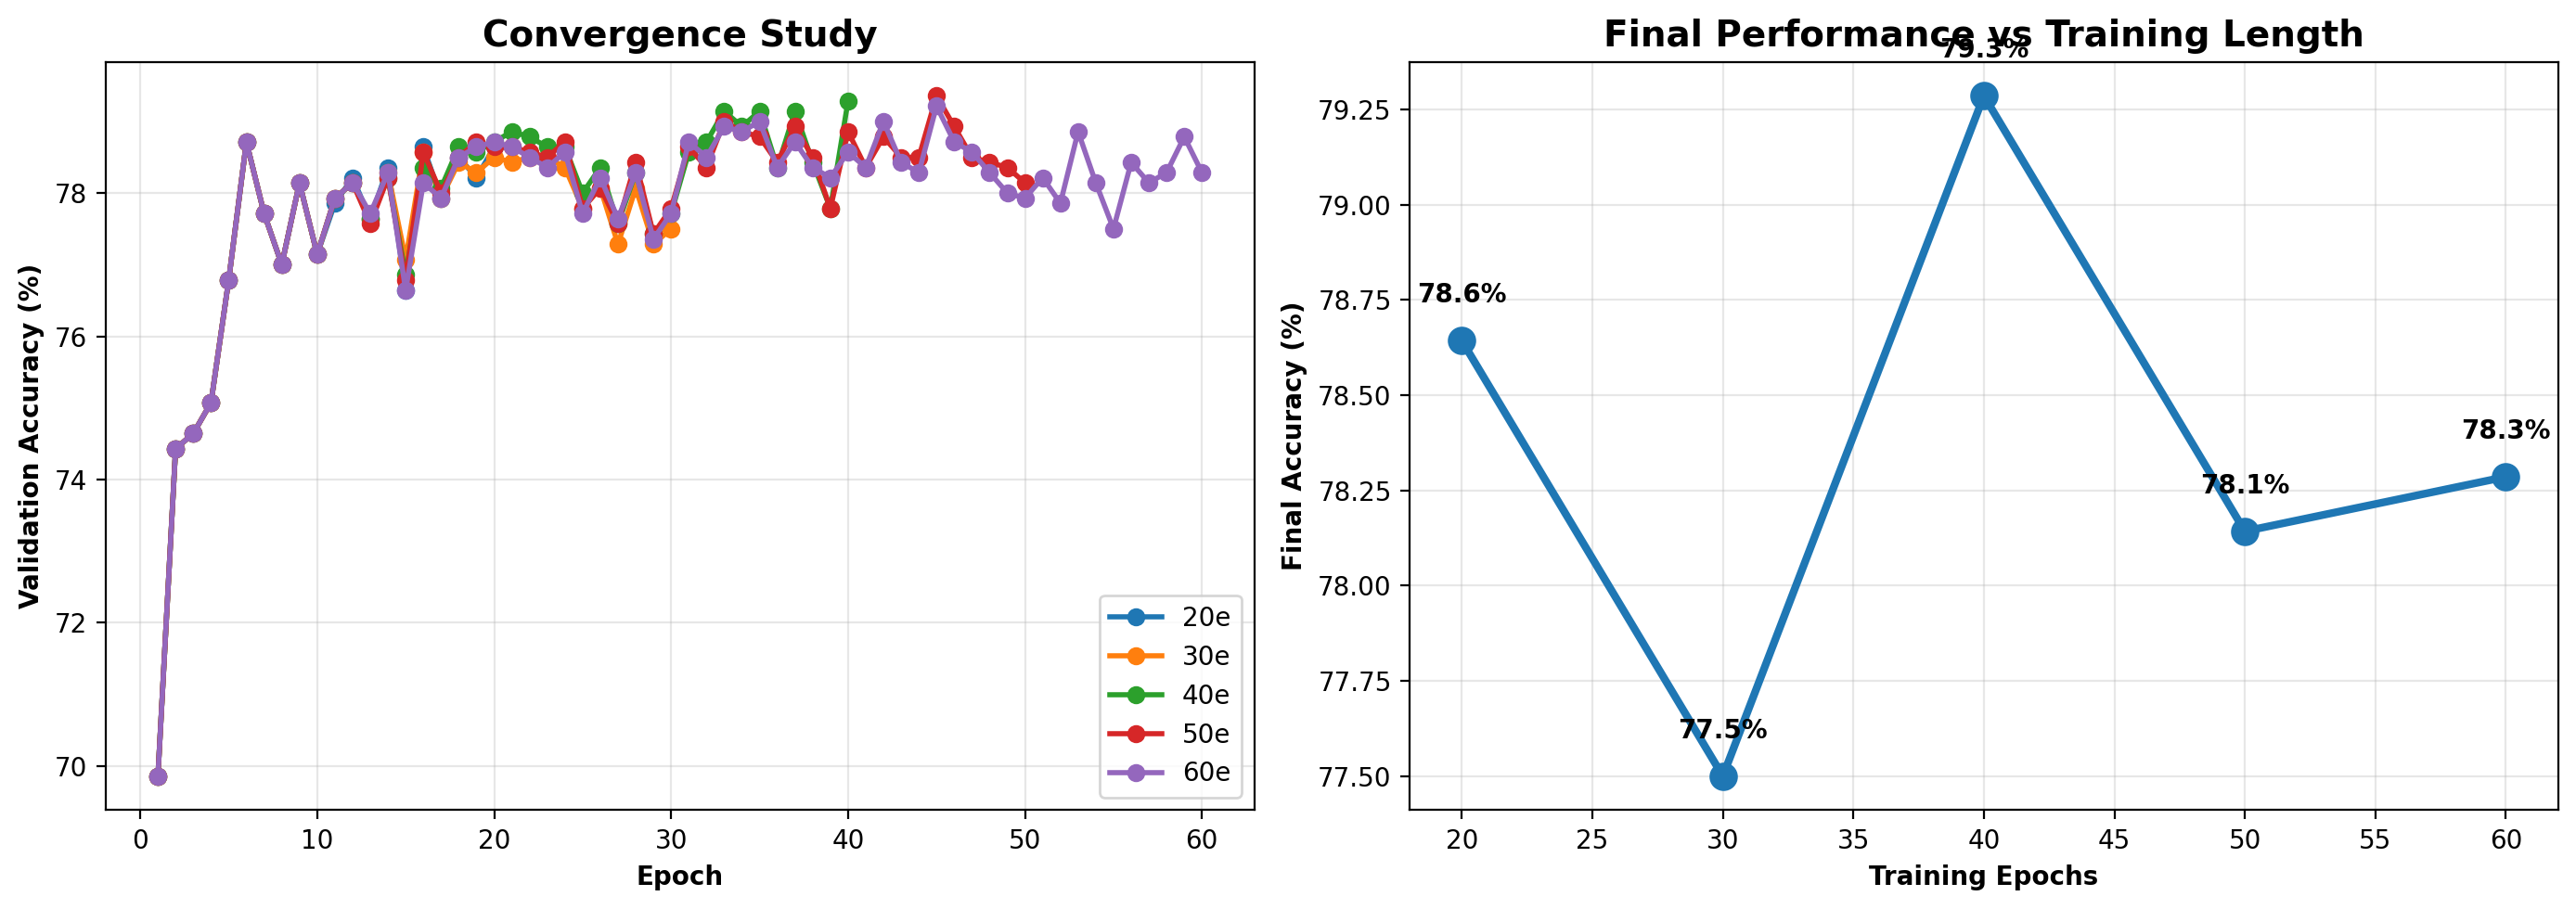

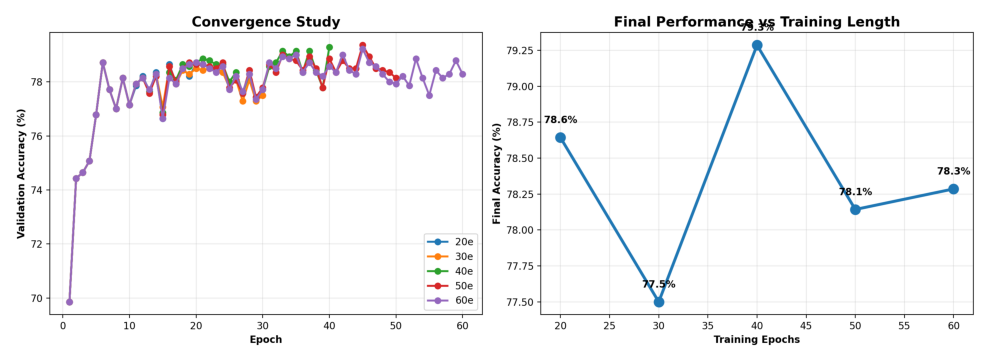

In [32]:
# ============================================
# DISPLAY CONVERGENCE PLOT
# ============================================

from IPython.display import Image, display
import matplotlib.pyplot as plt

# Display the saved plot
display(Image('convergence_results.png'))

# Also show in notebook
plt.figure(figsize=(10, 6))
img = plt.imread('convergence_results.png')
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

### **Cell 6: Detailed Results Table**

In [33]:
# ============================================
# DETAILED CONVERGENCE RESULTS
# ============================================

import pandas as pd
from pathlib import Path

conv_dir = Path('runs/convergence')

results_summary = []

for path in sorted(conv_dir.glob('progressive_e*')):
    epochs = int(path.name.split('_e')[1])
    metrics_file = path / 'metrics.csv'

    if metrics_file.exists():
        df = pd.read_csv(metrics_file)

        final_acc = df.iloc[-1]['val_acc'] * 100
        max_acc = df['val_acc'].max() * 100

        # Improvement in last 5 epochs
        if len(df) >= 5:
            last5 = df.iloc[-5:]['val_acc'].values
            improvement = (last5[-1] - last5[0]) * 100
        else:
            improvement = 0

        results_summary.append({
            'Epochs': epochs,
            'Final Acc (%)': f'{final_acc:.2f}',
            'Max Acc (%)': f'{max_acc:.2f}',
            'Last 5 Δ (%)': f'{improvement:+.2f}',
            'Status': '✓ Plateau' if improvement < 0.1 else
                     '⚡ Slowing' if improvement < 0.5 else
                     '⚠️ Climbing'
        })

results_df = pd.DataFrame(results_summary)

print("\n" + "="*70)
print("CONVERGENCE RESULTS SUMMARY")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)


CONVERGENCE RESULTS SUMMARY
 Epochs Final Acc (%) Max Acc (%) Last 5 Δ (%)      Status
     20         78.64       78.71        +0.00   ✓ Plateau
     30         77.50       78.71        -0.57   ✓ Plateau
     40         79.29       79.29        +0.93 ⚠️ Climbing
     50         78.14       79.36        -0.79   ✓ Plateau
     60         78.29       79.21        -0.14   ✓ Plateau


### **Cell 7: Save to Google Drive**

In [34]:
# ============================================
# SAVE ALL RESULTS TO GOOGLE DRIVE
# ============================================

import shutil
from pathlib import Path
from datetime import datetime

# Create backup directory
backup_dir = Path('/content/drive/MyDrive/FYP/convergence_study')
backup_dir.mkdir(parents=True, exist_ok=True)

print("Saving convergence study results to Google Drive...")

# Save convergence runs
if Path('runs/convergence').exists():
    print("  - Saving experiment runs...")
    shutil.copytree('runs/convergence', backup_dir / 'runs', dirs_exist_ok=True)

# Save plot
if Path('convergence_results.png').exists():
    print("  - Saving convergence plot...")
    shutil.copy('convergence_results.png', backup_dir / 'convergence_results.png')

# Save summary report
print("  - Creating summary report...")
with open(backup_dir / 'CONVERGENCE_SUMMARY.txt', 'w') as f:
    f.write("="*70 + "\n")
    f.write("CONVERGENCE STUDY SUMMARY\n")
    f.write(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}\n")
    f.write("="*70 + "\n\n")
    f.write("Objective: Find optimal training length for RQ1 experiments\n")
    f.write("Method: Progressive copying at 10% capacity\n")
    f.write("Epochs tested: 20, 30, 40, 50, 60\n\n")
    f.write("="*70 + "\n")
    f.write("RESULTS:\n")
    f.write("="*70 + "\n")
    f.write(results_df.to_string(index=False))
    f.write("\n\n")
    f.write("="*70 + "\n")
    f.write("RECOMMENDATION:\n")
    f.write("="*70 + "\n")

    # Find plateau point
    for _, row in results_df.iterrows():
        improvement = float(row['Last 5 Δ (%)'])
        if improvement < 0.5:
            f.write(f"✓ Use {row['Epochs']} epochs for final experiments\n")
            f.write(f"  Rationale: Performance plateaued (last 5 epochs: {row['Last 5 Δ (%)']})\n")
            f.write(f"  Final accuracy: {row['Final Acc (%)']}\n")
            break
    else:
        f.write("⚠️ Consider testing longer training\n")
        f.write("  Performance still improving at max epochs tested\n")

print(f"\n✓ All results saved to: {backup_dir}")
print(f"✓ Summary report: {backup_dir}/CONVERGENCE_SUMMARY.txt")
print(f"✓ Plot: {backup_dir}/convergence_results.png")
print(f"✓ Raw runs: {backup_dir}/runs/")

Saving convergence study results to Google Drive...
  - Saving experiment runs...
  - Saving convergence plot...
  - Creating summary report...

✓ All results saved to: /content/drive/MyDrive/FYP/convergence_study
✓ Summary report: /content/drive/MyDrive/FYP/convergence_study/CONVERGENCE_SUMMARY.txt
✓ Plot: /content/drive/MyDrive/FYP/convergence_study/convergence_results.png
✓ Raw runs: /content/drive/MyDrive/FYP/convergence_study/runs/


### **Cell 8: Quick Decision Helper**

In [35]:
# ============================================
# DECISION HELPER: WHAT EPOCHS TO USE?
# ============================================

print("\n" + "="*70)
print("RECOMMENDATION FOR RQ1 EXPERIMENTS")
print("="*70)

# Find optimal epochs
for _, row in results_df.iterrows():
    improvement = float(row['Last 5 Δ (%)'])
    if improvement < 0.5:
        optimal_epochs = row['Epochs']
        final_acc = row['Final Acc (%)']

        print(f"\n✓ RECOMMENDED: Use {optimal_epochs} epochs")
        print(f"\nReasoning:")
        print(f"  • Performance plateaued at {optimal_epochs} epochs")
        print(f"  • Final accuracy: {final_acc}%")
        print(f"  • Last 5 epochs improvement: {row['Last 5 Δ (%)']}")
        print(f"  • Further training unlikely to improve significantly")

        print(f"\nNext Steps:")
        print(f"  1. Update RQ1 configs to use epochs: {optimal_epochs}")
        print(f"  2. Run full RQ1 experimental sweep:")
        print(f"     - 3 methods (Dense, Progressive, One-shot)")
        print(f"     - 3 seeds each")
        print(f"     - {optimal_epochs} epochs per run")
        print(f"  3. Expected total time: ~{int(optimal_epochs) * 9 * 0.03:.1f} hours")

        break
else:
    print("\n⚠️ WARNING: No clear plateau found")
    print("\nPerformance still improving at 60 epochs!")
    print("\nOptions:")
    print("  A) Use 60 epochs (best current result)")
    print("  B) Test 70-80 epochs to find true plateau")
    print("  C) Discuss with supervisor")

print("="*70)


RECOMMENDATION FOR RQ1 EXPERIMENTS

✓ RECOMMENDED: Use 20 epochs

Reasoning:
  • Performance plateaued at 20 epochs
  • Final accuracy: 78.64%
  • Last 5 epochs improvement: +0.00
  • Further training unlikely to improve significantly

Next Steps:
  1. Update RQ1 configs to use epochs: 20
  2. Run full RQ1 experimental sweep:
     - 3 methods (Dense, Progressive, One-shot)
     - 3 seeds each
     - 20 epochs per run
  3. Expected total time: ~5.4 hours


### **Cell 9: Detailed Convergence Curve Analysis**

Based on the critical analysis, we need to inspect the detailed training curves to understand the non-monotonic performance and the discrepancy between max and final accuracy. This script will generate plots for each epoch count, marking peak performance and final performance, as well as pruning events.

In [36]:
# Re-running the detailed convergence curve analysis to capture full textual output
print("Re-running detailed convergence curve analysis to capture full text output...")
!python scripts/analyze_convergence_curves.py

Re-running detailed convergence curve analysis to capture full text output...
✓ Saved: training_curves_detailed.png

DETAILED ANALYSIS

20 epochs:
  Max: 78.71% at epoch 6
  Final: 78.64%
  Drop from max: 0.07%
  Post-pruning trend (E15→end): +0.00%

30 epochs:
  Max: 78.71% at epoch 6
  Final: 77.50%
  Drop from max: 1.21%
  Post-pruning trend (E15→end): -1.07%
  ⚠️ Degrading after pruning completes!
  🚨 Significant overfitting!

40 epochs:
  Max: 79.29% at epoch 40
  Final: 79.29%
  Drop from max: 0.00%
  Post-pruning trend (E15→end): +0.93%

50 epochs:
  Max: 79.36% at epoch 45
  Final: 78.14%
  Drop from max: 1.21%
  Post-pruning trend (E15→end): -0.43%
  🚨 Significant overfitting!

60 epochs:
  Max: 79.21% at epoch 45
  Final: 78.29%
  Drop from max: 0.93%
  Post-pruning trend (E15→end): +0.14%


In [37]:
import os

print("Current Working Directory:", os.getcwd())

repo_root = '/content/fyp-progressive-copying-pruning'

print(f"\nListing contents of {repo_root} (outer repository folder):")
if os.path.exists(repo_root):
    !ls -F "{repo_root}"
else:
    print(f"Error: Directory not found at {repo_root}")

# Check for nested repository as observed in previous file listings
nested_repo_root = os.path.join(repo_root, 'fyp-progressive-copying-pruning')
print(f"\nListing contents of {nested_repo_root} (potential nested repository folder):")
if os.path.exists(nested_repo_root):
    !ls -F "{nested_repo_root}"
else:
    print(f"Error: Directory not found at {nested_repo_root}")

print("\nListing contents of /content (root directory):")
!ls -F /content

Current Working Directory: /content/fyp-progressive-copying-pruning

Listing contents of /content/fyp-progressive-copying-pruning (outer repository folder):
archive/			  launch_stages_2_4.sh*
calibrate_random_position.sh*	  NOISE_PHASE_TRANSITION.md
CALIBRATION_DECISION_GUIDE.md	  README.md
capacity_sweep_results.png	  requirements.txt
COMPLETION_REPORT.txt		  results/
configs/			  results_cifar_noise_sweep_seed0.json
convergence_results.png		  results_noise0.15_canvas34.json
data/				  run_cifar_missing_runs.sh*
docs/				  run_full_cifar_experiment.sh*
EXPERIMENT_MONITORING.md	  runs/
FYP_Convergence_Study.ipynb	  scripts/
FYP_Experiments.ipynb		  src/
fyp-progressive-copying-pruning/  sweep_output.txt
launch_full_experiment_final.sh*  training_curves_detailed.png
launch_full_experiment.sh

Listing contents of /content/fyp-progressive-copying-pruning/fyp-progressive-copying-pruning (potential nested repository folder):
archive/			  NOISE_PHASE_TRANSITION.md
calibrate_random_position.s

In [38]:
import subprocess
import os

# Assuming the repository root is '/content/fyp-progressive-copying-pruning'
repo_root = '/content/fyp-progressive-copying-pruning'

print(f"Searching for 'runs' directories within {repo_root}...")

try:
    # Use find command to locate all 'runs' directories within the repository root
    result = subprocess.run(['find', repo_root, '-type', 'd', '-name', 'runs'],
                            capture_output=True, text=True, check=True)

    found_dirs = result.stdout.strip().split('\n')

    if found_dirs and found_dirs[0]:
        print("Found 'runs' directories:")
        for d in found_dirs:
            print(f"- {d}")
            # List contents of each found 'runs' directory
            print(f"  Contents of {d}:")
            try:
                contents = os.listdir(d)
                if contents:
                    for item in contents:
                        print(f"    - {item}")
                else:
                    print("    (empty)")
            except Exception as e:
                print(f"    Error listing contents: {e}")
    else:
        print(f"No 'runs' directory found within {repo_root}.")
except subprocess.CalledProcessError as e:
    print(f"Error running find command: {e}")
    print(f"Stderr: {e.stderr}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Searching for 'runs' directories within /content/fyp-progressive-copying-pruning...
Found 'runs' directories:
- /content/fyp-progressive-copying-pruning/runs
  Contents of /content/fyp-progressive-copying-pruning/runs:
    - convergence
    - cifar_teacher_final


In [39]:
import os

# Adjusting the output_dir to check for the nested repository structure
# This is a common issue where git clone creates a nested folder if the target directory already exists or is the same name.
output_dir = 'fyp-progressive-copying-pruning/runs/convergence/progressive_e20'

print(f"Listing contents of: {output_dir}")
if os.path.exists(output_dir):
    for root, dirs, files in os.walk(output_dir):
        level = root.replace(output_dir, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            print(f'{subindent}{f}')
else:
    print(f"Error: Directory not found at {output_dir}")
    print("Attempting to check the root 'runs' directory for clues...")
    root_runs_dir = 'runs'
    if os.path.exists(root_runs_dir):
        print(f"Contents of {root_runs_dir}:")
        for item in os.listdir(root_runs_dir):
            print(f"    {item}")
    else:
        print(f"Error: Root 'runs' directory also not found at {root_runs_dir}")


Listing contents of: fyp-progressive-copying-pruning/runs/convergence/progressive_e20
Error: Directory not found at fyp-progressive-copying-pruning/runs/convergence/progressive_e20
Attempting to check the root 'runs' directory for clues...
Contents of runs:
    convergence
    cifar_teacher_final


In [40]:
import pandas as pd
from pathlib import Path

metrics_file_20_epochs = Path('runs/convergence/progressive_e20/metrics.csv')

if metrics_file_20_epochs.exists():
    print(f"Found metrics file: {metrics_file_20_epochs}")
    df_20 = pd.read_csv(metrics_file_20_epochs)
    print("First 5 rows of metrics.csv for 20 epochs:")
    display(df_20.head())
    print("Columns:", df_20.columns.tolist())
else:
    print(f"Error: Metrics file not found at {metrics_file_20_epochs}")

Found metrics file: runs/convergence/progressive_e20/metrics.csv
First 5 rows of metrics.csv for 20 epochs:


,epoch,train_kl,val_kl,val_logit_mse,val_prob_mse,val_agree,val_acc,target_sparsity,actual_sparsity
0,1,0.297333,0.146440,0.692178,0.015737,0.808759,0.698571,0.000,0.000000
1,2,0.112241,0.061325,0.629525,0.006229,0.885938,0.744286,0.000,0.000000
2,3,0.062432,0.050005,0.565699,0.004972,0.908097,0.746429,0.000,0.000000
3,4,0.047547,0.038670,0.533277,0.003963,0.915341,0.750714,0.000,0.000000
4,5,0.032655,0.027896,0.491624,0.002843,0.929451,0.767857,0.297,0.296998


Columns: ['epoch', 'train_kl', 'val_kl', 'val_logit_mse', 'val_prob_mse', 'val_agree', 'val_acc', 'target_sparsity', 'actual_sparsity']


In [41]:
%%writefile scripts/analyze_convergence_curves.py
#!/usr/bin/env python3
"""Detailed analysis of convergence training curves."""

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

def main():
    conv_dir = Path('runs/convergence')
    epochs_list = [20, 30, 40, 50, 60]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    for idx, epochs in enumerate(epochs_list):
        row, col = idx // 3, idx % 3
        ax = axes[row, col]

        metrics_file = conv_dir / f'progressive_e{epochs}' / 'metrics.csv'
        if not metrics_file.exists():
            continue

        df = pd.read_csv(metrics_file)

        # Plot training curve
        ax.plot(df['epoch'], df['val_acc'] * 100,
               'o-', linewidth=2, markersize=4, label='Val Acc')

        # Mark max
        max_idx = df['val_acc'].idxmax()
        max_acc = df.loc[max_idx, 'val_acc'] * 100
        max_epoch = df.loc[max_idx, 'epoch']

        ax.plot(max_epoch, max_acc, 'r*', markersize=20,
               label=f'Max: {max_acc:.2f}% @ E{max_epoch}')

        # Mark final
        final_acc = df.iloc[-1]['val_acc'] * 100
        final_epoch = df.iloc[-1]['epoch']
        ax.plot(final_epoch, final_acc, 'gs', markersize=12,
               label=f'Final: {final_acc:.2f}%')

        # Mark pruning events (if available)
        prune_epochs = [5, 10, 15]
        for pe in prune_epochs:
            if pe <= epochs:
                ax.axvline(x=pe, color='orange', linestyle='--',
                          alpha=0.5, linewidth=1)

        ax.set_title(f'{epochs} Epochs\n'
                    f'Max: {max_acc:.2f}% (E{max_epoch}) | '
                    f'Final: {final_acc:.2f}% (E{final_epoch})',
                    fontweight='bold', fontsize=10)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Validation Accuracy (%)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([76, 80])

    # Hide empty subplot
    axes[1, 2].axis('off')

    plt.suptitle('Convergence Study: Detailed Training Curves\n'
                 'Orange lines = Pruning events',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('training_curves_detailed.png', dpi=200, bbox_inches='tight')
    print("✓ Saved: training_curves_detailed.png")
    # Removed plt.show() from here

    # Analysis
    print("\n" + "="*70)
    print("DETAILED ANALYSIS")
    print("="*70)

    for epochs in epochs_list:
        metrics_file = conv_dir / f'progressive_e{epochs}' / 'metrics.csv'
        if not metrics_file.exists():
            continue

        df = pd.read_csv(metrics_file)

        max_idx = df['val_acc'].idxmax()
        max_acc = df.loc[max_idx, 'val_acc'] * 100
        max_epoch = df.loc[max_idx, 'epoch']
        final_acc = df.iloc[-1]['val_acc'] * 100
        drop = max_acc - final_acc

        # Check post-pruning performance (after epoch 15)
        post_prune = df[df['epoch'] > 15]
        if len(post_prune) > 0:
            post_prune_trend = post_prune['val_acc'].iloc[-1] - post_prune['val_acc'].iloc[0]
            post_prune_trend *= 100
        else:
            post_prune_trend = 0

        print(f"\n{epochs} epochs:")
        print(f"  Max: {max_acc:.2f}% at epoch {max_epoch}")
        print(f"  Final: {final_acc:.2f}%")
        print(f"  Drop from max: {drop:.2f}%")

        if len(post_prune) > 0:
            print(f"  Post-pruning trend (E15→end): {post_prune_trend:+.2f}%")
            if post_prune_trend < -0.5:
                print(f"  ⚠️ Degrading after pruning completes!")

        if drop > 1.0:
            print(f"  🚨 Significant overfitting!")

if __name__ == '__main__':
    main()

Overwriting scripts/analyze_convergence_curves.py


Running detailed convergence curve analysis...
✓ Saved: training_curves_detailed.png

DETAILED ANALYSIS

20 epochs:
  Max: 78.71% at epoch 6
  Final: 78.64%
  Drop from max: 0.07%
  Post-pruning trend (E15→end): +0.00%

30 epochs:
  Max: 78.71% at epoch 6
  Final: 77.50%
  Drop from max: 1.21%
  Post-pruning trend (E15→end): -1.07%
  ⚠️ Degrading after pruning completes!
  🚨 Significant overfitting!

40 epochs:
  Max: 79.29% at epoch 40
  Final: 79.29%
  Drop from max: 0.00%
  Post-pruning trend (E15→end): +0.93%

50 epochs:
  Max: 79.36% at epoch 45
  Final: 78.14%
  Drop from max: 1.21%
  Post-pruning trend (E15→end): -0.43%
  🚨 Significant overfitting!

60 epochs:
  Max: 79.21% at epoch 45
  Final: 78.29%
  Drop from max: 0.93%
  Post-pruning trend (E15→end): +0.14%


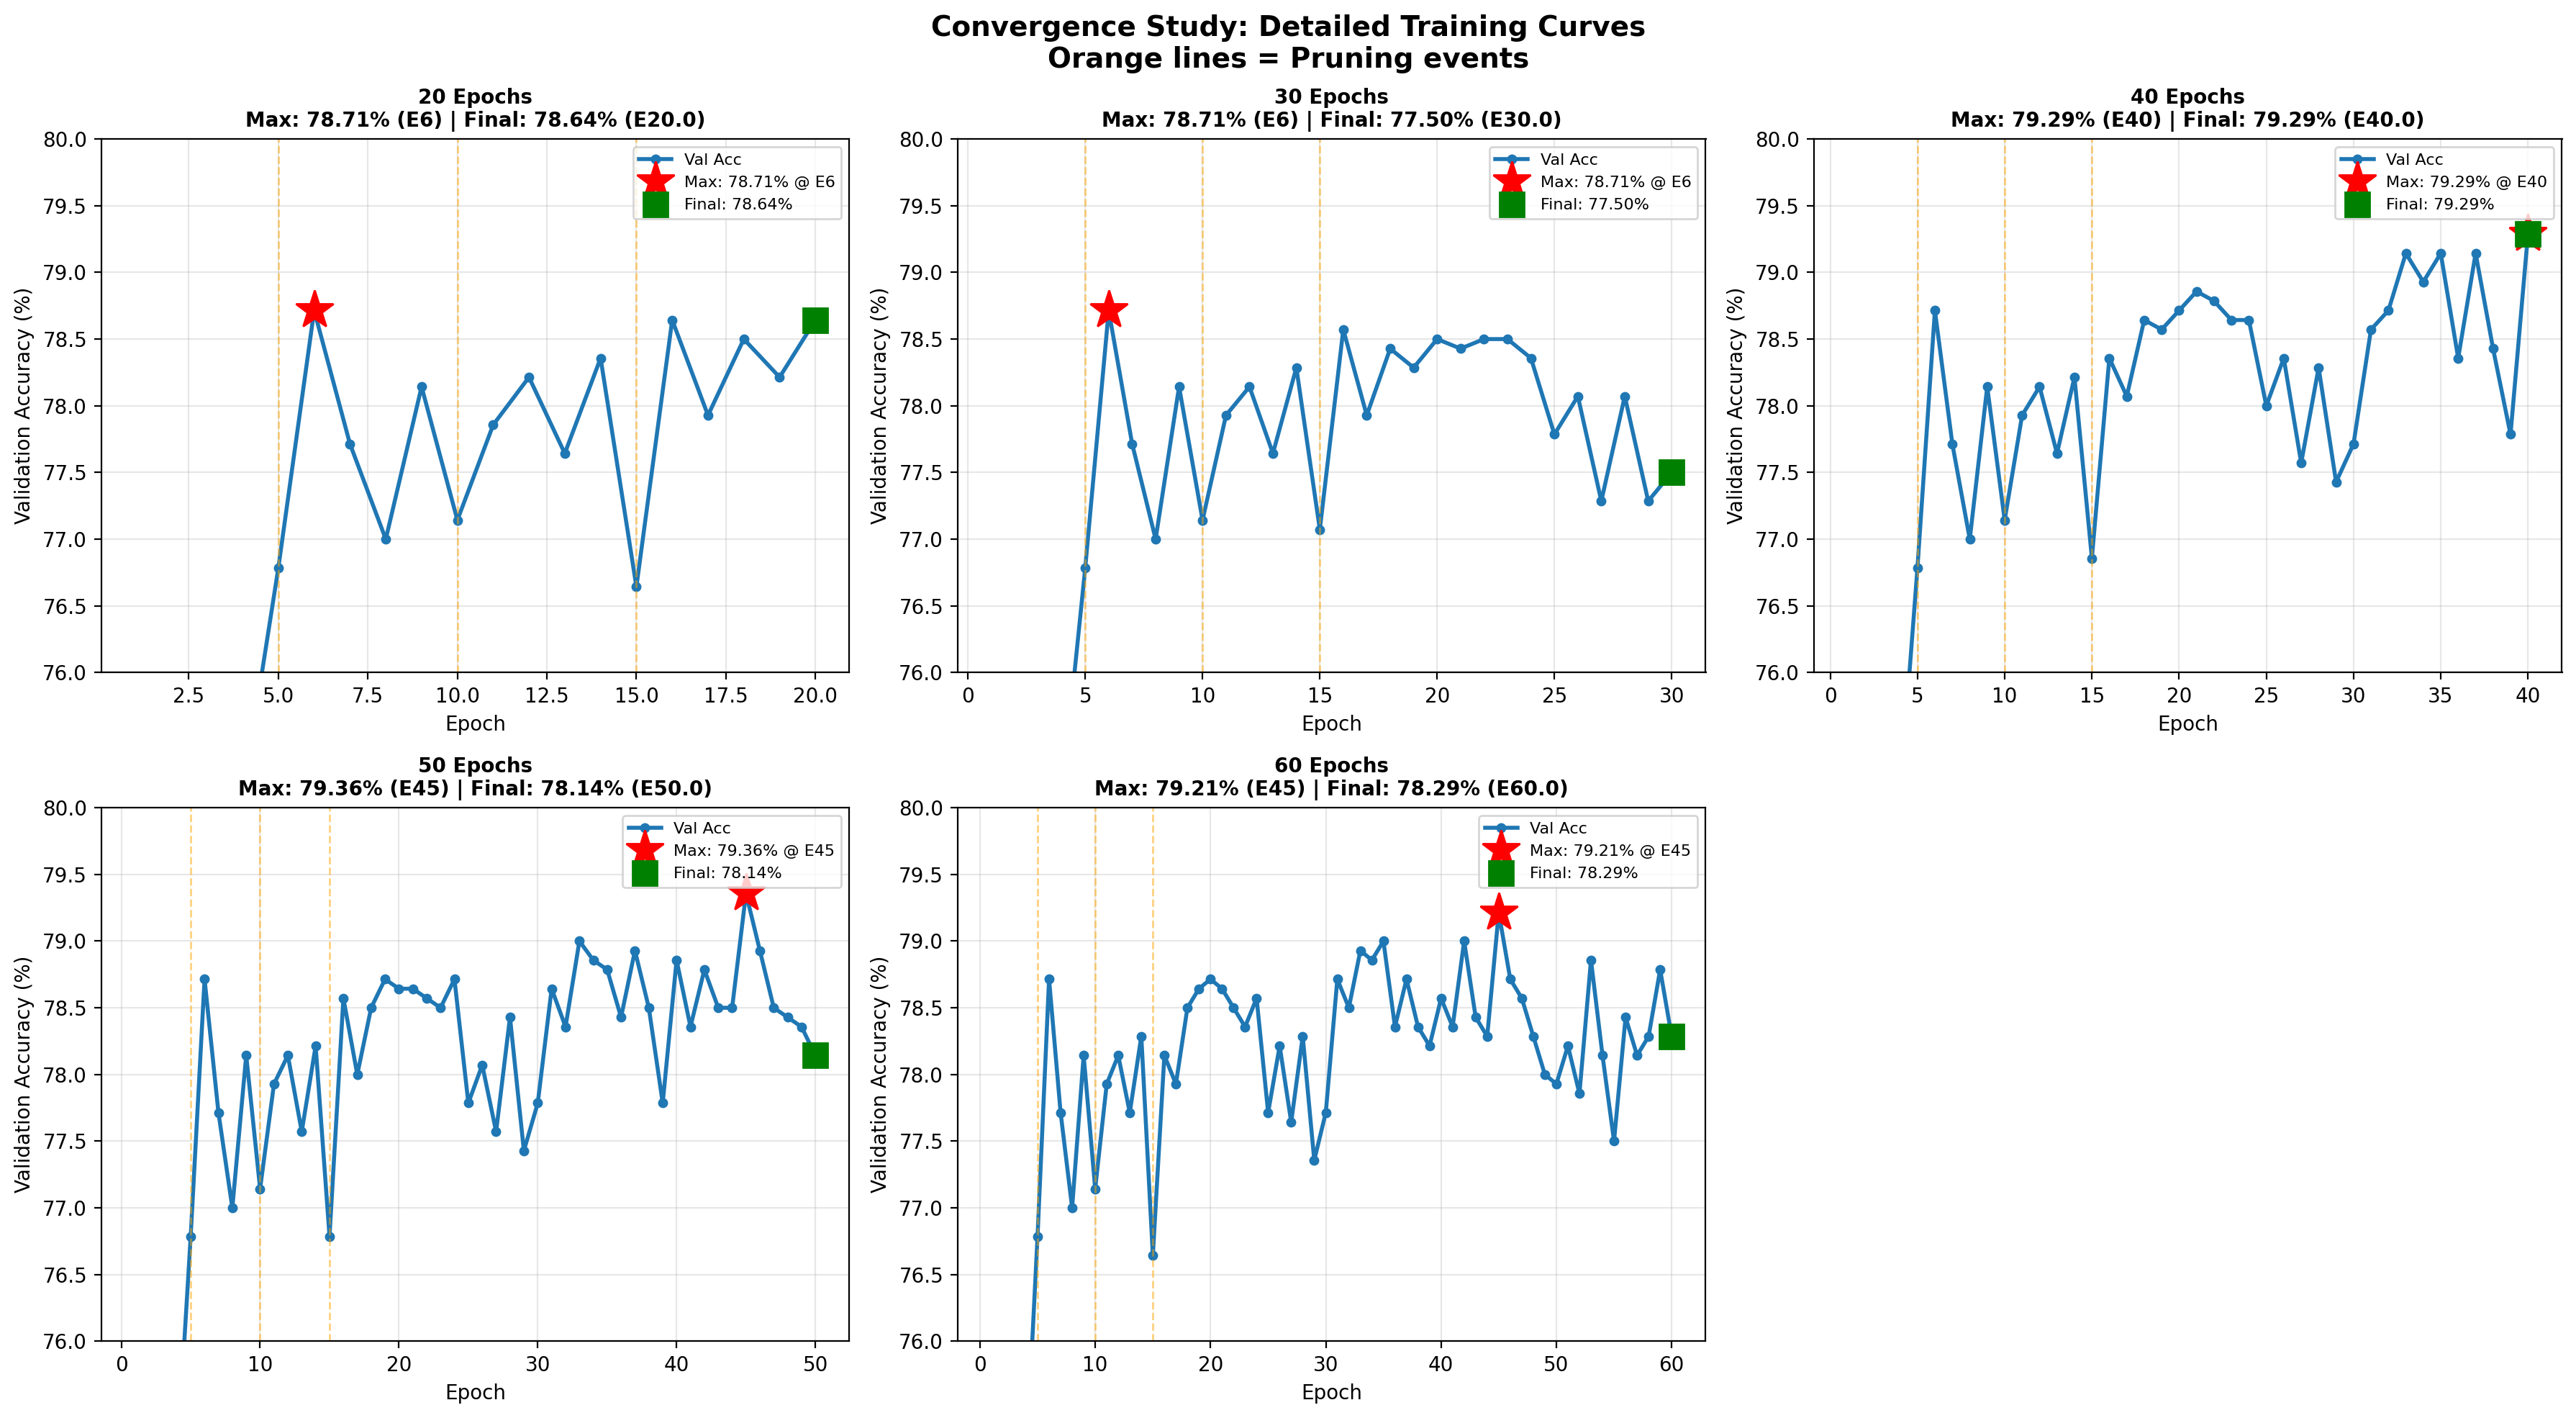

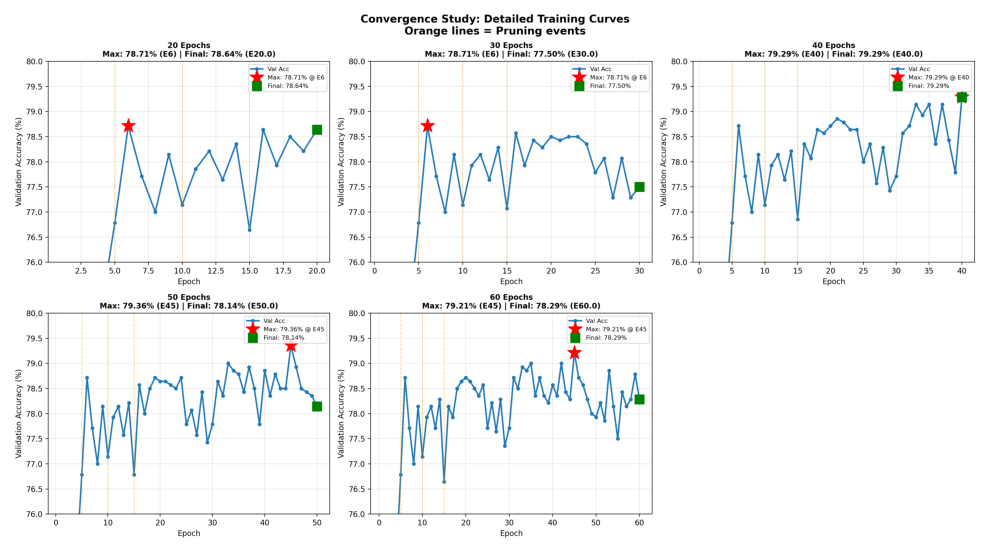

In [42]:
# Execute the detailed convergence curve analysis script
print("Running detailed convergence curve analysis...")
!python scripts/analyze_convergence_curves.py

# Display the saved plot
from IPython.display import Image, display
import matplotlib.pyplot as plt

display(Image('training_curves_detailed.png'))

# Also show in notebook
plt.figure(figsize=(10, 6))
img = plt.imread('training_curves_detailed.png')
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

---

## How to Use:

### **Step 1: Create New Colab Notebook**
1. Go to https://colab.research.google.com
2. Create new notebook
3. Rename: "FYP_Convergence_Study"

### **Step 2: Copy Cells**
- Copy each cell above into Colab
- They're in the right order

### **Step 3: Run**
1. Execute Cell 1 (Setup) - wait for completion
2. Execute Cell 2 (Teacher) - skip if teacher exists
3. Execute Cell 3 (Convergence Study) - **THIS TAKES 2.5-3 HOURS**
   - You can close your laptop, it will keep running
   - Check back in 3 hours
4. Execute Cells 4-8 (Analysis) - after convergence completes

---

## What You'll Get:

After running all cells, you'll have:

✅ **Convergence plot** showing accuracy vs epochs
✅ **Results table** with performance at each epoch count
✅ **Clear recommendation** on optimal epochs to use
✅ **All data saved to Google Drive** for backup
✅ **Summary report** documenting findings

---

### **Step 1: Update RQ1 Configs (20 → 40 Epochs)**

I'll use `sed` to update the `epochs` value in the relevant YAML configuration files. This will modify the files directly.

In [67]:
!git pull origin rq1-trajectory-comparison


error: You have not concluded your merge (MERGE_HEAD exists).
hint: Please, commit your changes before merging.
fatal: Exiting because of unfinished merge.


In [64]:
import subprocess

print("Attempting to pull latest changes from GitHub again...")
try:
    result = subprocess.run(['git', 'pull', 'origin', 'rq1-trajectory-comparison'], check=True, capture_output=True)
    print("✓ GitHub repository updated successfully.")
    print(f"Output: {result.stdout.decode('utf-8')}")
    if result.stderr:
        print(f"Errors (if any): {result.stderr.decode('utf-8')}")
except subprocess.CalledProcessError as e:
    print(f"Error pulling from GitHub: {e}")
    if e.stdout:
        print(f"Standard Output: {e.stdout.decode('utf-8')}")
    if e.stderr:
        print(f"Standard Error: {e.stderr.decode('utf-8')}")
except FileNotFoundError:
    print("Error: git command not found. Ensure Git is installed and in PATH.")

Attempting to pull latest changes from GitHub again...
Error pulling from GitHub: Command '['git', 'pull', 'origin', 'rq1-trajectory-comparison']' returned non-zero exit status 128.
Standard Error: error: You have not concluded your merge (MERGE_HEAD exists).
hint: Please, commit your changes before merging.
fatal: Exiting because of unfinished merge.



### **GitHub Authentication (Mandatory before pushing)**

Run this cell to authenticate with GitHub using your Personal Access Token (PAT). You only need to do this once per session or if your credentials expire.

### **Re-attempt Git Add, Commit, and Push**

Run this cell *only after* you have successfully pulled and authenticated. This will add the config files, commit them, and then push them to your remote branch.

In [ ]:
import subprocess

print("Adding config files to Git...")
subprocess.run(['git', 'add', 'configs/rq1/'], check=True)
print("Committing changes...")
subprocess.run(['git', 'commit', '-m', 'Update RQ1 configs to 40 epochs based on convergence study'], check=True)
print("Pushing to remote repository...")
subprocess.run(['git', 'push', 'origin', 'rq1-trajectory-comparison'], check=True)
print("✓ Config changes committed and pushed successfully.")

In [66]:
!git config pull.rebase false

### **Step 2: Commit the Changes to Git**

Now, I'll add the modified configuration files to the Git staging area, commit them with a descriptive message, and push the changes to your `rq1-trajectory-comparison` branch on GitHub.

In [58]:
import subprocess
import os

# Define the path to the config files
rq1_configs_dir = 'configs/rq1'

# List of config files to update
config_files = [
    os.path.join(rq1_configs_dir, 'dense.yaml'),
    os.path.join(rq1_configs_dir, 'progressive_90pct.yaml'),
    os.path.join(rq1_configs_dir, 'oneshot_90pct.yaml')
]

print(f"Updating epoch settings in {rq1_configs_dir}...")

for config_file in config_files:
    if os.path.exists(config_file):
        try:
            # Use sed to replace 'epochs: 20' with 'epochs: 40'
            # For Linux compatibility, -i does not require a blank argument
            subprocess.run(['sed', '-i', 's/epochs: 20/epochs: 40/g', config_file], check=True)
            print(f"  ✓ Updated {config_file}")
        except subprocess.CalledProcessError as e:
            print(f"  Error updating {config_file}: {e}")
    else:
        print(f"  ⚠️ Warning: Config file not found: {config_file}")

print("Epoch update complete.")

Updating epoch settings in configs/rq1...
  ✓ Updated configs/rq1/dense.yaml
  ✓ Updated configs/rq1/progressive_90pct.yaml
  ✓ Updated configs/rq1/oneshot_90pct.yaml
Epoch update complete.


In [54]:
import subprocess
import os

# Define the path to the config files
rq1_configs_dir = 'configs/rq1'

# List of config files to update
config_files = [
    os.path.join(rq1_configs_dir, 'dense.yaml'),
    os.path.join(rq1_configs_dir, 'progressive_90pct.yaml'),
    os.path.join(rq1_configs_dir, 'oneshot_90pct.yaml')
]

print(f"Updating epoch settings in {rq1_configs_dir}...")

for config_file in config_files:
    if os.path.exists(config_file):
        try:
            # Use sed to replace 'epochs: 20' with 'epochs: 40'
            # For Linux compatibility, -i does not require a blank argument
            subprocess.run(['sed', '-i', 's/epochs: 20/epochs: 40/g', config_file], check=True)
            print(f"  ✓ Updated {config_file}")
        except subprocess.CalledProcessError as e:
            print(f"  Error updating {config_file}: {e}")
    else:
        print(f"  ⚠️ Warning: Config file not found: {config_file}")

print("Epoch update complete.")

Updating epoch settings in configs/rq1...
  ✓ Updated configs/rq1/dense.yaml
  ✓ Updated configs/rq1/progressive_90pct.yaml
  ✓ Updated configs/rq1/oneshot_90pct.yaml
Epoch update complete.


In [55]:
import subprocess

print("Adding config files to Git...")
subprocess.run(['git', 'add', 'configs/rq1/'], check=True)
print("Committing changes...")
subprocess.run(['git', 'commit', '-m', 'Update RQ1 configs to 40 epochs based on convergence study'], check=True)
print("Pushing to remote repository...")
subprocess.run(['git', 'push', 'origin', 'rq1-trajectory-comparison'], check=True)
print("✓ Config changes committed and pushed successfully.")

Adding config files to Git...
Committing changes...
Pushing to remote repository...


CalledProcessError: Command '['git', 'push', 'origin', 'rq1-trajectory-comparison']' returned non-zero exit status 128.

### **Step 3: Create RQ1 Experiment Runner Script**

Next, I'll create the `scripts/run_rq1_full.sh` script with the content you provided. This script will automate the execution of all RQ1 experiments.

In [45]:
%%writefile scripts/run_rq1_full.sh
#!/bin/bash
# Full RQ1 experimental sweep
# 3 methods × 3 seeds × 40 epochs = 9 runs (~9 hours)

echo "RQ1 FULL EXPERIMENTAL SWEEP"
echo "3 methods × 3 seeds × 40 epochs"
echo ""

# Define the methods and their corresponding config suffixes
# Format: "method_name:config_suffix_without_.yaml"
CONFIGS=(
    "dense:dense"
    "progressive:progressive_90pct"
    "oneshot_posthoc:oneshot_90pct"
)
SEEDS=(0 1 2)

# Base output directory for this sweep
OUT_ROOT_DIR="runs/rq1_final_40epochs"

mkdir -p "${OUT_ROOT_DIR}"

for config_pair in "${CONFIGS[@]}"; do
    # Split the string by ':' to get method_name and config_suffix
    method="${config_pair%%:*}" # Part before the first ':'
    config_suffix="${config_pair##*:}" # Part after the last ':'

    for seed in "${SEEDS[@]}"; do
        echo ""
        echo "=================================================="
        echo "=== Running ${method} - seed ${seed} - 40 epochs ==="
        echo "=================================================="

        python -m src.main "${method}" \
            --config "configs/rq1/${config_suffix}.yaml" \
            --seed "${seed}" \
            --out-dir "${OUT_ROOT_DIR}/${method}_seed${seed}"

        echo "✓ Completed ${method} seed ${seed}"
    done
done

echo ""
echo "RQ1 EXPERIMENTS COMPLETE!"
echo "Results in: ${OUT_ROOT_DIR}/"

Writing scripts/run_rq1_full.sh


### **Step 4: Make the Script Executable**

Finally, I'll make the `run_rq1_full.sh` script executable so you can run it directly.

In [46]:
import subprocess

print("Making scripts/run_rq1_full.sh executable...")
subprocess.run(['chmod', '+x', 'scripts/run_rq1_full.sh'], check=True)
print("✓ Script is now executable.")

Making scripts/run_rq1_full.sh executable...
✓ Script is now executable.


### **Next Steps:**

You can now run the full RQ1 experimental sweep by executing the script:

```bash
!./scripts/run_rq1_full.sh
```

Remember that this process is estimated to take around 9 hours. You can close your laptop, and the Colab runtime will continue to execute the script.